<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Finding Outliers**


Estimated time needed: **30** minutes


In this lab, you will work with a cleaned dataset to perform exploratory data analysis or EDA. 
You will explore the distribution of key variables and focus on identifying outliers in this lab.


## Objectives


In this lab, you will perform the following:


-  Analyze the distribution of key variables in the dataset.

-  Identify and remove outliers using statistical methods.

-  Perform relevant statistical and correlation analysis.


#### Install and import the required libraries


In [2]:
!pip install pandas
!pip install matplotlib
!pip install seaborn

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.0/11.0 MB 144.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.7/16.7 MB 166.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [pandas]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 160.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 158.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 99.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 178.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [matplotlib]


<h3>Step 1: Load and Explore the Dataset</h3>


Load the dataset into a DataFrame and examine the structure of the data.


In [8]:
file_url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv"

#Create the dataframe
df = pd.read_csv(file_url)

#Display the top 10 records
df.head()


,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


<h3>Step 2: Plot the Distribution of Industry</h3>


Explore how respondents are distributed across different industries.

- Plot a bar chart to visualize the distribution of respondents by industry.

- Highlight any notable trends.


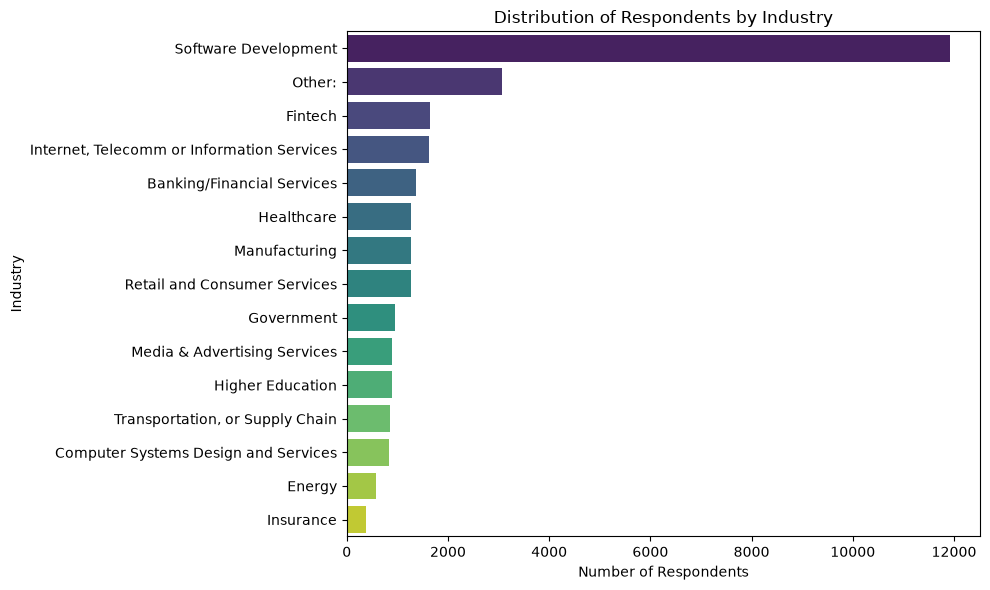

Top 3 Industries:
Industry
Software Development    11918
Other:                   3077
Fintech                  1641
Name: count, dtype: int64

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Count frequency of each industry
industry_counts = df['Industry'].value_counts()

# Plot horizontal bar chart without triggering the warning
plt.figure(figsize=(10, 6))
sns.barplot(
    x=industry_counts.values,
    y=industry_counts.index,
    hue=industry_counts.index,
    palette='viridis',
    legend=False
)

plt.title('Distribution of Respondents by Industry')
plt.xlabel('Number of Respondents')
plt.ylabel('Industry')
plt.tight_layout()
plt.show()

# Print top trends directly
print("Top 3 Industries:")
print(industry_counts.head(3))

<h3>Step 3: Identify High Compensation Outliers</h3>


Identify respondents with extremely high yearly compensation.

- Calculate basic statistics (mean, median, and standard deviation) for `ConvertedCompYearly`.

- Identify compensation values exceeding a defined threshold (e.g., 3 standard deviations above the mean).


In [11]:
##Write your code here
# Calculate basic statistics
mean_comp = df['ConvertedCompYearly'].mean()
median_comp = df['ConvertedCompYearly'].median()
std_comp = df['ConvertedCompYearly'].std()

print(f"Mean: {mean_comp:.2f}")
print(f"Median: {median_comp:.2f}")
print(f"Standard Deviation: {std_comp:.2f}")

# Define threshold (3 standard deviations above the mean)
threshold = mean_comp + (3 * std_comp)

# Identify high compensation outliers
high_outliers = df[df['ConvertedCompYearly'] > threshold]

print(f"\nOutlier Threshold (> 3 Std Dev): {threshold:.2f}")
print(f"Number of High Compensation Outliers: {len(high_outliers)}")

Mean: 86155.29
Median: 65000.00
Standard Deviation: 186756.97

Outlier Threshold (> 3 Std Dev): 646426.21
Number of High Compensation Outliers: 89

<h3>Step 4: Detect Outliers in Compensation</h3>


Identify outliers in the `ConvertedCompYearly` column using the IQR method.

- Calculate the Interquartile Range (IQR).

- Determine the upper and lower bounds for outliers.

- Count and visualize outliers using a box plot.


Q1 (25th percentile): 32712.00
Q3 (75th percentile): 107971.50
IQR: 75259.50
Lower Bound: -80177.25
Upper Bound: 220860.75
Total Outliers Count: 978

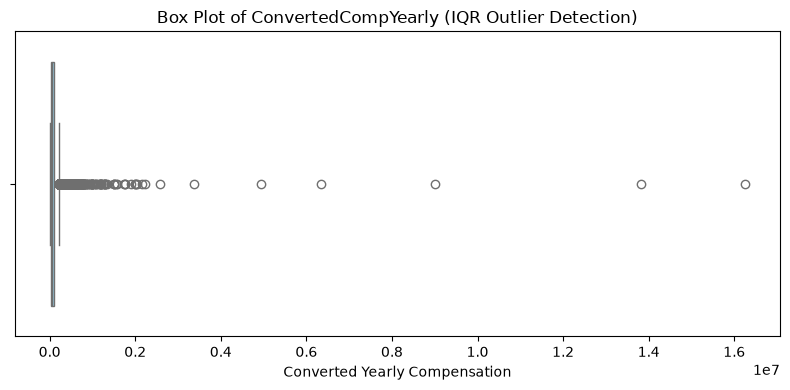

In [12]:
##Write your code here
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Calculate Q1, Q3, and IQR
Q1 = df['ConvertedCompYearly'].quantile(0.25)
Q3 = df['ConvertedCompYearly'].quantile(0.75)
IQR = Q3 - Q1

# 2. Determine lower and upper bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# 3. Identify and count outliers
outliers = df[(df['ConvertedCompYearly'] < lower_bound) | (df['ConvertedCompYearly'] > upper_bound)]

print(f"Q1 (25th percentile): {Q1:.2f}")
print(f"Q3 (75th percentile): {Q3:.2f}")
print(f"IQR: {IQR:.2f}")
print(f"Lower Bound: {lower_bound:.2f}")
print(f"Upper Bound: {upper_bound:.2f}")
print(f"Total Outliers Count: {len(outliers)}")

# 4. Visualize using a box plot
plt.figure(figsize=(8, 4))
sns.boxplot(x=df['ConvertedCompYearly'], color='skyblue')

plt.title('Box Plot of ConvertedCompYearly (IQR Outlier Detection)')
plt.xlabel('Converted Yearly Compensation')
plt.tight_layout()
plt.show() 

<h3>Step 5: Remove Outliers and Create a New DataFrame</h3>


Remove outliers from the dataset.

- Create a new DataFrame excluding rows with outliers in `ConvertedCompYearly`.
- Validate the size of the new DataFrame.


In [13]:
##Write your code here
# 1. Create a new DataFrame excluding outliers based on upper and lower bounds
df_no_outliers = df[
    (df["ConvertedCompYearly"] >= lower_bound)
    & (df["ConvertedCompYearly"] <= upper_bound)
]

# 2. Validate the size of the original and new DataFrames
print(f"Original DataFrame shape: {df.shape}")
print(f"New DataFrame shape (no outliers): {df_no_outliers.shape}")
print(f"Number of rows removed: {len(df) - len(df_no_outliers)}") 

Original DataFrame shape: (65437, 114)
New DataFrame shape (no outliers): (22457, 114)
Number of rows removed: 42980

<h3>Step 6: Correlation Analysis</h3>


Analyze the correlation between `Age` (transformed) and other numerical columns.

- Map the `Age` column to approximate numeric values.

- Compute correlations between `Age` and other numeric variables.

- Visualize the correlation matrix.


Correlation Matrix:
                     ResponseId  CompTotal   WorkExp  JobSatPoints_1  \
ResponseId             1.000000  -0.000000  0.011955       -0.002406   
CompTotal             -0.000000   0.000000  0.028766       -0.004891   
WorkExp                0.011955   0.028766  1.000000       -0.026490   
JobSatPoints_1        -0.002406  -0.004891 -0.026490        1.000000   
JobSatPoints_4        -0.015738  -0.002719 -0.067241        0.445710   
JobSatPoints_5        -0.014197  -0.003033 -0.104525        0.633765   
JobSatPoints_6        -0.001908  -0.006311 -0.065352        0.618618   
JobSatPoints_7         0.001843  -0.005893 -0.101461        0.603157   
JobSatPoints_8        -0.002968  -0.004585 -0.046958        0.627385   
JobSatPoints_9         0.001991  -0.004494 -0.088090        0.597527   
JobSatPoints_10       -0.005365  -0.003198 -0.113707        0.585087   
JobSatPoints_11       -0.005865  -0.003045 -0.108279        0.607792   
ConvertedCompYearly   -0.008363   0.080457  

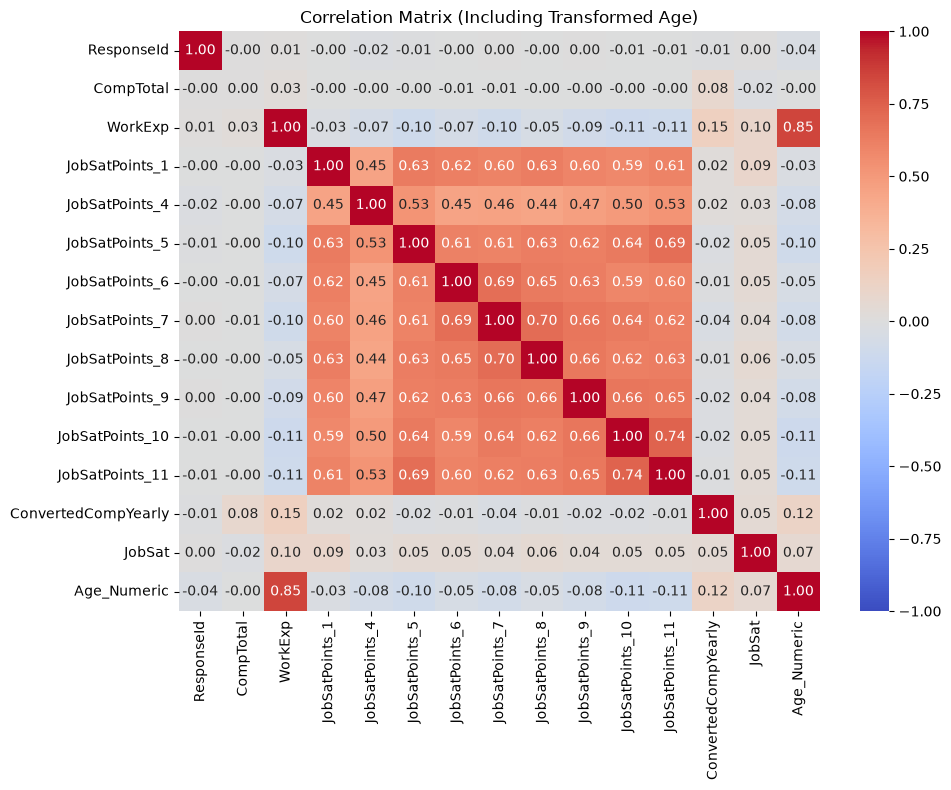

In [14]:
##Write your code here
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# 1. Map categorical Age ranges to approximate numeric midpoint values
age_mapping = {
    "Under 18 years old": 15,
    "18-24 years old": 21,
    "25-34 years old": 29.5,
    "35-44 years old": 39.5,
    "45-54 years old": 49.5,
    "55-64 years old": 59.5,
    "65 years or older": 70,
    "Prefer not to say": None,
}

# Apply mapping (works whether operating on df or df_no_outliers)
df["Age_Numeric"] = df["Age"].map(age_mapping)

# 2. Compute correlation matrix for numeric columns
correlation_matrix = df.corr(numeric_only=True)
print("Correlation Matrix:")
print(correlation_matrix)

# 3. Visualize the correlation matrix using a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", vmin=-1, vmax=1)

plt.title("Correlation Matrix (Including Transformed Age)")
plt.tight_layout()
plt.show() 

<h3> Summary </h3>


In this lab, you developed essential skills in **Exploratory Data Analysis (EDA)** with a focus on outlier detection and removal. Specifically, you:


- Loaded and explored the dataset to understand its structure.

- Analyzed the distribution of respondents across industries.

- Identified and removed high compensation outliers using statistical thresholds and the Interquartile Range (IQR) method.

- Performed correlation analysis, including transforming the `Age` column into numeric values for better analysis.


<!--
## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|               
|2024-10-1|1.1|Madhusudan Moole|Reviewed and updated lab|                                                                                    
|2024-09-29|1.0|Raghul Ramesh|Created lab|
--!>


Copyright © IBM Corporation. All rights reserved.
